<a href="https://colab.research.google.com/github/shivanishrees/.github/blob/main/Social_Network_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install networkx pandas matplotlib

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/content/social_media_engagement_dataset.csv")

In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/social_media_engagement_dataset.csv")

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape: (10000, 8)

Columns:
['platform', 'post_type', 'post_length', 'views', 'likes', 'comments', 'shares', 'engagement_rate']

First 5 Rows:


,platform,post_type,post_length,views,likes,comments,shares,engagement_rate
0,Facebook,Text,62,91660,2968,276,346,0.039166
1,Instagram,Video,104,113115,4164,632,406,0.045989
2,Facebook,Video,46,36043,3125,188,100,0.094692
3,Facebook,Image,39,124886,5970,948,578,0.060023
4,Instagram,Video,42,82831,8212,1104,334,0.116502



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   platform         10000 non-null  object 
 1   post_type        10000 non-null  object 
 2   post_length      10000 non-null  int64  
 3   views            10000 non-null  int64  
 4   likes            10000 non-null  int64  
 5   comments         10000 non-null  int64  
 6   shares           10000 non-null  int64  
 7   engagement_rate  10000 non-null  float64
dtypes: float64(1), int64(5), object(2)
memory usage: 625.1+ KB


In [5]:
# STEP 3: Calculate total engagement for each post

df["engagement"] = (
    df["likes"] +
    df["comments"] +
    df["shares"]
)

print("Engagement column created successfully!\n")

display(
    df[
        ["platform", "post_type", "likes", "comments", "shares", "engagement"]
    ].head()
)

Engagement column created successfully!



,platform,post_type,likes,comments,shares,engagement
0,Facebook,Text,2968,276,346,3590
1,Instagram,Video,4164,632,406,5202
2,Facebook,Video,3125,188,100,3413
3,Facebook,Image,5970,948,578,7496
4,Instagram,Video,8212,1104,334,9650


In [6]:
# STEP 4: Create Platform–Post Type relationships

network_data = (
    df.groupby(["platform", "post_type"])["engagement"]
    .sum()
    .reset_index()
)

print("Network relationships created:\n")

display(network_data)

Network relationships created:



,platform,post_type,engagement
0,Facebook,Image,9915653
1,Facebook,Text,9190145
2,Facebook,Video,9244765
3,Instagram,Image,11475078
4,Instagram,Text,11133404
5,Instagram,Video,11759424
6,Twitter,Image,7563494
7,Twitter,Text,7380241
8,Twitter,Video,7485443


In [7]:
# STEP 5: Create the NetworkX graph

G = nx.Graph()

# Add platform-post type relationships as edges
for _, row in network_data.iterrows():
    G.add_edge(
        row["platform"],
        row["post_type"],
        weight=row["engagement"]
    )

print("NetworkX graph created successfully!\n")

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

print("\nNodes:")
print(list(G.nodes()))

print("\nEdges with engagement weights:")
print(list(G.edges(data=True)))

NetworkX graph created successfully!

Number of nodes: 6
Number of edges: 9

Nodes:
['Facebook', 'Image', 'Text', 'Video', 'Instagram', 'Twitter']

Edges with engagement weights:
[('Facebook', 'Image', {'weight': 9915653}), ('Facebook', 'Text', {'weight': 9190145}), ('Facebook', 'Video', {'weight': 9244765}), ('Image', 'Instagram', {'weight': 11475078}), ('Image', 'Twitter', {'weight': 7563494}), ('Text', 'Instagram', {'weight': 11133404}), ('Text', 'Twitter', {'weight': 7380241}), ('Video', 'Instagram', {'weight': 11759424}), ('Video', 'Twitter', {'weight': 7485443})]


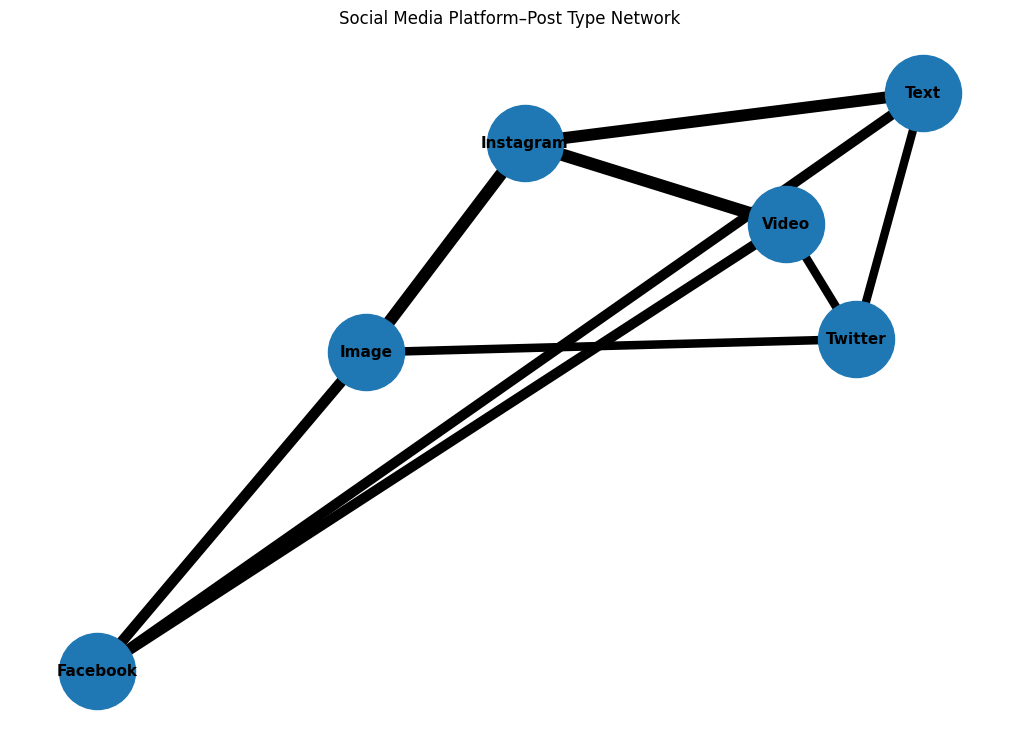

In [8]:
# STEP 6: Visualize the network

plt.figure(figsize=(10, 7))

# Calculate positions for the nodes
pos = nx.spring_layout(G, seed=42)

# Get edge weights
weights = [G[u][v]["weight"] for u, v in G.edges()]

# Scale the weights so they can be displayed as edge thickness
max_weight = max(weights)
edge_widths = [1 + (w / max_weight) * 8 for w in weights]

# Draw the network
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=11,
    font_weight="bold",
    width=edge_widths
)

plt.title("Social Media Platform–Post Type Network")
plt.show()

In [9]:
# STEP 7: Basic Network Properties

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
degrees = dict(G.degree())
average_degree = sum(degrees.values()) / num_nodes

print("===== BASIC NETWORK PROPERTIES =====")

print("Number of Nodes:", num_nodes)
print("Number of Edges:", num_edges)
print("Network Density:", round(density, 4))
print("Average Degree:", round(average_degree, 2))

print("\n===== DEGREE OF EACH NODE =====")

for node, degree in degrees.items():
    print(f"{node}: {degree}")

===== BASIC NETWORK PROPERTIES =====
Number of Nodes: 6
Number of Edges: 9
Network Density: 0.6
Average Degree: 3.0

===== DEGREE OF EACH NODE =====
Facebook: 3
Image: 3
Text: 3
Video: 3
Instagram: 3
Twitter: 3


In [10]:
# STEP 8: Degree Centrality

degree_centrality = nx.degree_centrality(G)

# Convert results into a DataFrame
degree_df = pd.DataFrame(
    list(degree_centrality.items()),
    columns=["Node", "Degree Centrality"]
)

# Sort from highest to lowest
degree_df = degree_df.sort_values(
    by="Degree Centrality",
    ascending=False
).reset_index(drop=True)

print("===== DEGREE CENTRALITY =====\n")

display(degree_df)

===== DEGREE CENTRALITY =====



,Node,Degree Centrality
0,Facebook,0.6
1,Image,0.6
2,Text,0.6
3,Video,0.6
4,Instagram,0.6
5,Twitter,0.6


In [11]:
# STEP 9: Betweenness Centrality

betweenness_centrality = nx.betweenness_centrality(G)

# Convert results into a DataFrame
betweenness_df = pd.DataFrame(
    list(betweenness_centrality.items()),
    columns=["Node", "Betweenness Centrality"]
)

# Sort from highest to lowest
betweenness_df = betweenness_df.sort_values(
    by="Betweenness Centrality",
    ascending=False
).reset_index(drop=True)

print("===== BETWEENNESS CENTRALITY =====\n")

display(betweenness_df)

===== BETWEENNESS CENTRALITY =====



,Node,Betweenness Centrality
0,Facebook,0.1
1,Image,0.1
2,Text,0.1
3,Video,0.1
4,Instagram,0.1
5,Twitter,0.1


In [12]:
# STEP 10: Closeness Centrality

closeness_centrality = nx.closeness_centrality(G)

# Convert results into a DataFrame
closeness_df = pd.DataFrame(
    list(closeness_centrality.items()),
    columns=["Node", "Closeness Centrality"]
)

# Sort from highest to lowest
closeness_df = closeness_df.sort_values(
    by="Closeness Centrality",
    ascending=False
).reset_index(drop=True)

print("===== CLOSENESS CENTRALITY =====\n")

display(closeness_df)

===== CLOSENESS CENTRALITY =====



,Node,Closeness Centrality
0,Facebook,0.714286
1,Image,0.714286
2,Text,0.714286
3,Video,0.714286
4,Instagram,0.714286
5,Twitter,0.714286


In [13]:
# STEP 11: Calculate all four centrality measures

degree_centrality = nx.degree_centrality(G)

betweenness_centrality = nx.betweenness_centrality(G)

closeness_centrality = nx.closeness_centrality(G)

eigenvector_centrality = nx.eigenvector_centrality(G)

# Create one DataFrame containing all results
centrality_df = pd.DataFrame({
    "Node": list(G.nodes()),
    "Degree Centrality": [
        degree_centrality[node] for node in G.nodes()
    ],
    "Betweenness Centrality": [
        betweenness_centrality[node] for node in G.nodes()
    ],
    "Closeness Centrality": [
        closeness_centrality[node] for node in G.nodes()
    ],
    "Eigenvector Centrality": [
        eigenvector_centrality[node] for node in G.nodes()
    ]
})

# Sort by degree centrality
centrality_df = centrality_df.sort_values(
    by="Degree Centrality",
    ascending=False
).reset_index(drop=True)

# Round values for readability
centrality_df = centrality_df.round(4)

print("===== CENTRALITY ANALYSIS =====\n")

display(centrality_df)

===== CENTRALITY ANALYSIS =====



,Node,Degree Centrality,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality
0,Facebook,0.6,0.1,0.7143,0.4082
1,Image,0.6,0.1,0.7143,0.4082
2,Text,0.6,0.1,0.7143,0.4082
3,Video,0.6,0.1,0.7143,0.4082
4,Instagram,0.6,0.1,0.7143,0.4082
5,Twitter,0.6,0.1,0.7143,0.4082


In [14]:
# STEP 12: Analyze weighted relationships

# Create a table of all network edges and their weights
edge_df = pd.DataFrame(
    [
        {
            "Platform": u,
            "Post Type": v,
            "Total Engagement": data["weight"]
        }
        for u, v, data in G.edges(data=True)
    ]
)

# Sort from highest to lowest engagement
edge_df = edge_df.sort_values(
    by="Total Engagement",
    ascending=False
).reset_index(drop=True)

print("===== PLATFORM–POST TYPE ENGAGEMENT =====\n")

display(edge_df)

# Find the strongest relationship
strongest = edge_df.iloc[0]

print("\n===== STRONGEST RELATIONSHIP =====")
print("Platform:", strongest["Platform"])
print("Post Type:", strongest["Post Type"])
print("Total Engagement:", strongest["Total Engagement"])

===== PLATFORM–POST TYPE ENGAGEMENT =====



,Platform,Post Type,Total Engagement
0,Video,Instagram,11759424
1,Image,Instagram,11475078
2,Text,Instagram,11133404
3,Facebook,Image,9915653
4,Facebook,Video,9244765
5,Facebook,Text,9190145
6,Image,Twitter,7563494
7,Video,Twitter,7485443
8,Text,Twitter,7380241



===== STRONGEST RELATIONSHIP =====
Platform: Video
Post Type: Instagram
Total Engagement: 11759424


In [15]:
# STEP 13: Community Detection using Louvain method

try:
    communities = nx.community.louvain_communities(
        G,
        weight="weight",
        seed=42
    )

    print("===== COMMUNITIES DETECTED =====\n")

    for i, community in enumerate(communities, start=1):
        print(f"Community {i}:")
        print(sorted(community))
        print()

except AttributeError:
    print("Louvain community detection is not available in this NetworkX version.")
    print("Run: !pip install -U networkx")

===== COMMUNITIES DETECTED =====

Community 1:
['Facebook', 'Image']

Community 2:
['Instagram', 'Text', 'Twitter', 'Video']



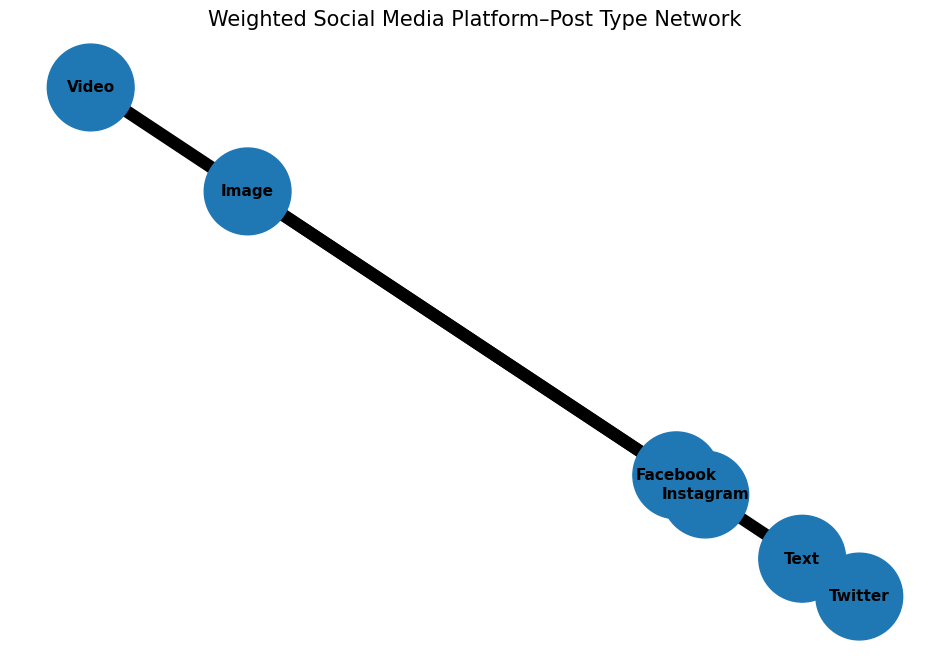

In [16]:
# STEP 14: Final Network Visualization

plt.figure(figsize=(12, 8))

# Position nodes
pos = nx.spring_layout(G, seed=42, k=1.5)

# -----------------------------
# Node sizes based on centrality
# -----------------------------
node_sizes = [
    1500 + degree_centrality[node] * 4000
    for node in G.nodes()
]

# -----------------------------
# Edge widths based on engagement
# -----------------------------
weights = [
    G[u][v]["weight"]
    for u, v in G.edges()
]

max_weight = max(weights)

edge_widths = [
    1 + (weight / max_weight) * 8
    for weight in weights
]

# -----------------------------
# Draw NetworkX graph
# -----------------------------
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=11,
    font_weight="bold"
)

plt.title(
    "Weighted Social Media Platform–Post Type Network",
    fontsize=15
)

plt.axis("off")
plt.show()

In [18]:
# STEP 16: Verify the actual network connections

print("===== NETWORK EDGES =====\n")

for u, v, data in G.edges(data=True):
    print(f"{u} -- {v} | Engagement: {data['weight']}")

===== NETWORK EDGES =====

Facebook -- Image | Engagement: 9915653
Facebook -- Text | Engagement: 9190145
Facebook -- Video | Engagement: 9244765
Image -- Instagram | Engagement: 11475078
Image -- Twitter | Engagement: 7563494
Text -- Instagram | Engagement: 11133404
Text -- Twitter | Engagement: 7380241
Video -- Instagram | Engagement: 11759424
Video -- Twitter | Engagement: 7485443


In [17]:
# STEP 15: Final Network Analysis Summary

results_df = pd.DataFrame({
    "Node": list(G.nodes()),
    "Degree": [
        G.degree(node)
        for node in G.nodes()
    ],
    "Degree Centrality": [
        degree_centrality[node]
        for node in G.nodes()
    ],
    "Betweenness Centrality": [
        betweenness_centrality[node]
        for node in G.nodes()
    ],
    "Closeness Centrality": [
        closeness_centrality[node]
        for node in G.nodes()
    ],
    "Eigenvector Centrality": [
        eigenvector_centrality[node]
        for node in G.nodes()
    ]
})

results_df = results_df.round(4)

# Sort by degree centrality
results_df = results_df.sort_values(
    "Degree Centrality",
    ascending=False
).reset_index(drop=True)

print("===== FINAL NETWORK ANALYSIS =====\n")

display(results_df)

print("\n===== NETWORK SUMMARY =====")

print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())
print("Network Density:", round(nx.density(G), 4))
print("Average Degree:", round(average_degree, 4))

===== FINAL NETWORK ANALYSIS =====



,Node,Degree,Degree Centrality,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality
0,Facebook,3,0.6,0.1,0.7143,0.4082
1,Image,3,0.6,0.1,0.7143,0.4082
2,Text,3,0.6,0.1,0.7143,0.4082
3,Video,3,0.6,0.1,0.7143,0.4082
4,Instagram,3,0.6,0.1,0.7143,0.4082
5,Twitter,3,0.6,0.1,0.7143,0.4082



===== NETWORK SUMMARY =====
Number of Nodes: 6
Number of Edges: 9
Network Density: 0.6
Average Degree: 3.0


In [19]:
# STEP 16: Verify the actual network connections

print("===== NETWORK EDGES =====\n")

for u, v, data in G.edges(data=True):
    print(f"{u} -- {v} | Engagement: {data['weight']}")

===== NETWORK EDGES =====

Facebook -- Image | Engagement: 9915653
Facebook -- Text | Engagement: 9190145
Facebook -- Video | Engagement: 9244765
Image -- Instagram | Engagement: 11475078
Image -- Twitter | Engagement: 7563494
Text -- Instagram | Engagement: 11133404
Text -- Twitter | Engagement: 7380241
Video -- Instagram | Engagement: 11759424
Video -- Twitter | Engagement: 7485443


In [20]:
# STEP 17: Weighted Degree Analysis

weighted_degree = dict(G.degree(weight="weight"))

weighted_degree_df = pd.DataFrame(
    list(weighted_degree.items()),
    columns=["Node", "Weighted Degree"]
)

weighted_degree_df = weighted_degree_df.sort_values(
    by="Weighted Degree",
    ascending=False
).reset_index(drop=True)

print("===== WEIGHTED DEGREE (TOTAL ENGAGEMENT) =====\n")

display(weighted_degree_df)

print("\n===== MOST ENGAGED NODE =====")

top_node = weighted_degree_df.iloc[0]

print("Node:", top_node["Node"])
print("Total Engagement:", top_node["Weighted Degree"])

===== WEIGHTED DEGREE (TOTAL ENGAGEMENT) =====



,Node,Weighted Degree
0,Instagram,34367906
1,Image,28954225
2,Video,28489632
3,Facebook,28350563
4,Text,27703790
5,Twitter,22429178



===== MOST ENGAGED NODE =====
Node: Instagram
Total Engagement: 34367906


===== ENGAGEMENT MATRIX =====



post_type,Image,Text,Video
platform,,,
Facebook,9915653,9190145,9244765
Instagram,11475078,11133404,11759424
Twitter,7563494,7380241,7485443


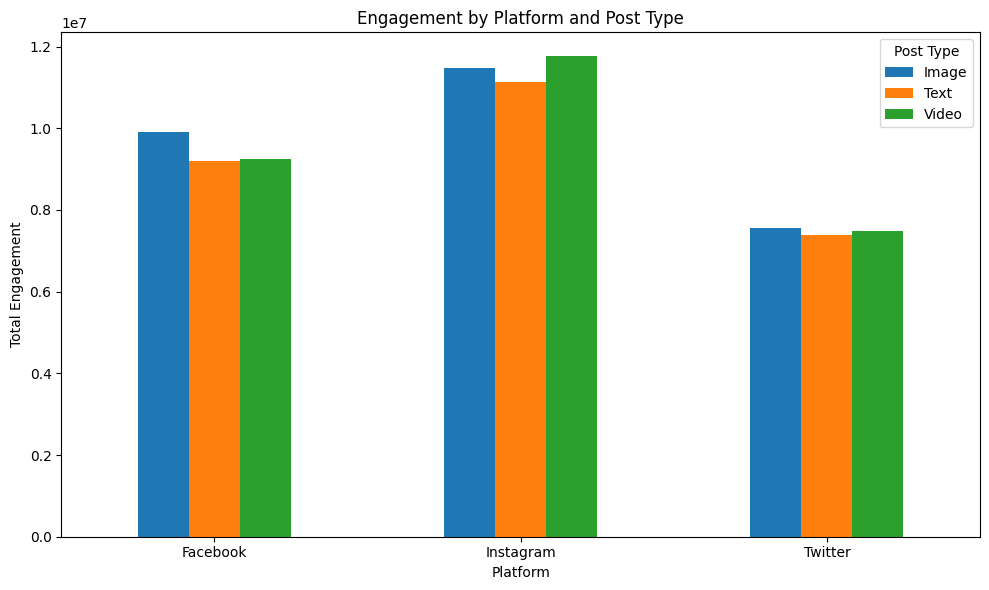

In [21]:
# STEP 18: Platform–Post Type Engagement Comparison

# Create a matrix of engagement values
engagement_matrix = network_data.pivot(
    index="platform",
    columns="post_type",
    values="engagement"
)

print("===== ENGAGEMENT MATRIX =====\n")
display(engagement_matrix)

# Plot the comparison
engagement_matrix.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Engagement by Platform and Post Type")
plt.xlabel("Platform")
plt.ylabel("Total Engagement")
plt.xticks(rotation=0)
plt.legend(title="Post Type")
plt.tight_layout()
plt.show()